# Multimodal financial Research Agent with Hybrid search
Build an intelligent agent that can search financial document (RAG) and live market data 

This notebool convers:
- Hybryd Search (RAG)
- Live finance research
- Agent with dual tools
- Financial analysis 
- Metadata filtering

In [1]:
import warnings 
warnings.filterwarnings('ignore')

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
import sys
sys.path.append("D:/Cursos/Agentes/financial_deep_research_agent")

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.agents import create_agent
from langchain.messages import HumanMessage, SystemMessage, ToolMessage, AIMessage
from langchain.tools import tool

from agent.rag_tools import hybrid_search

In [5]:
result = hybrid_search.invoke({"query":"what is the revenue of apple in 2024"})

In [ ]:
from agent.prompts import MULTIMODEL_AGENT_PROMPT

model = ChatGoogleGenerativeAI(model= "gemini-3-pro-preview", temperature=0)

### Define live finance research tool

In [ ]:
import subprocess
import sys

@tool
def live_finance_researcher(query: str) -> str:
    """Research stocks usinf yahoo finance MCP async function.
    Call this tool to get:
    - current stock prices and real-time maket data
    - lastest dinancial news
    - stock recimmendationand analyst rating
    - recents stock actions(splits, dividends)
    
    args:
        query: the financial research question about current market data
    Return: 
         Research results from yahoo finance"""

    code=f"""
import asyncio
from scripts_py.yahoo_mcp import finance_research
asyncio.run(finance_research('{query}'))"""

    result = subprocess.run([sys.executable, '-c', code], capture_output=True, text=True, cwd="D:/Cursos/Agentes/financial_deep_research_agent")
    return result.stdout if result.stdout else "No se obtuvo respuesta"

In [23]:
resp = live_finance_researcher.invoke({'query': 'What is the lastest stock price of apple'})

Error: 


In [24]:
resp

'The latest stock price of Apple (AAPL) is $300.23.\n'

### Create financial research agent with memory

In [ ]:
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

conn = sqlite3.connect('D:/Cursos/Agentes/financial_deep_research_agent/data/sqlite/financial_research_agent.db', check_same_thread=False)
checkpointer = SqliteSaver(conn=conn)

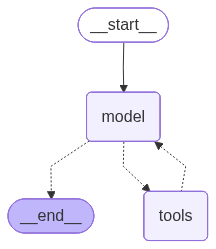

In [28]:
def get_agent():
    agent = create_agent(
        model=model,
        tools=[live_finance_researcher, hybrid_search],
        system_prompt=MULTIMODEL_AGENT_PROMPT,
        checkpointer=checkpointer
    )
    return agent

agent = get_agent()
agent

In [46]:
config = {'configurable': {'thread_id':'session1'}}
query = 'what is the apples cash flows in 2023'

agent = get_agent()
resp = agent.invoke({'messages': [HumanMessage(query)]}, config=config)

In [50]:
resp

{'messages': [HumanMessage(content='what is the apples cash flow in 2023', additional_kwargs={}, response_metadata={}, id='680b5f70-d93e-4256-b5b9-b9c672dd952e'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'hybrid_search', 'arguments': '{"query": "Apple cash flow 2023"}'}, '__gemini_function_call_thought_signatures__': {'f9cd0d9a-8789-4e78-a454-6a0185f87b47': 'CtQBAQw51sevZsrZC1vRZE1soroF1uHSeuZYbMLwhvarYu9/ehIuLREFBJDnioRSfniIXtITMa8ef4+zZmYuPcjdB9exx193OIJoRErQ+5sOUR2CiRQG2hTnWZm5BPsJwNrUI6+7fMfhmXk3mUM1pH+HLCfMYPS3wR8SvFsnS6ruAA0CSlbJdQ2SgUOuy7PeJn9+BQwBmA0dmqu15a/FtZMUbyzU/c1MXJCa0QNmVKgc0KvnoKQ7+CaqBEPPAwrnL4jshVuM5wlR7/4GPIp2xvMEIzeZLL8='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e361d-fdb2-7f31-8353-e83d9415d671-0', tool_calls=[{'name': 'hybrid_search', 'args': {'query': 'Apple cash flow 2023'}, 'id': 'f9cd0d9a-8789-4e78-a454-6a0185f87b47', 'ty

In [49]:
print(resp['messages'][-1].text)

Apple's cash flow for the year ended September 30, 2023, was:

*   **Cash generated by operating activities:** $110,543 million
*   **Cash generated by investing activities:** $3,705 million
*   **Cash used in financing activities:** $(108,488) million
*   **Increase in cash, cash equivalents and restricted cash:** $5,760 million
*   **Cash, cash equivalents and restricted cash, ending balances:** $30,737 million

Source: apple 10-k 2023.md, page 59


In [29]:
def stream_agent_response(agent, query, thread_id = "default"):
    config = {'configurable': {'thread_id':'session1'}}

    for chunk in agent.stream({'messages': [HumanMessage(query)]},stream_mode="messages",config=config):
        messages = chunk[0] if isinstance(chunk, tuple) else chunk

        #handle ai messages with tool calls
        if isinstance(messages, AIMessage) and messages.tool_calls:
             for tool_call in messages.tool_calls:
                 print(f"\n Tool called: {tool_call['name']}")
                 print(f"\n Args: {tool_call['args']}")
                 print("\n")
        elif isinstance(messages, ToolMessage):
            print(f"\n Tool result (length: {len(messages.text)})")
            print()
        
        elif isinstance(messages, AIMessage):
            print(messages.text, end="", flush=True)

In [30]:
query = 'what is the amazon cash flows in 2024'
agent = get_agent()

stream_agent_response(agent, query, 'session2')

Amazon's cash flows for the year ended December 31, 2024, were as follows:

*   **Net cash provided by operating activities:** $115,877 million
*   **Net cash used in investing activities:** $(94,342) million
*   **Net cash used in financing activities:** $(11,812) million
*   **Net increase in cash, cash equivalents, and restricted cash:** $8,422 million
*   **Cash, cash equivalents, and restricted cash, end of period:** $82,312 million

Source: amazon 10-k 2024.md, page 68

In [20]:
query = 'what is the current stock price of apple (aapl) and show lastest news'
agent = get_agent()

stream_agent_response(agent, query, 'session3')


 Tool called: live_finance_researcher

 Args: {'query': 'current stock price and latest news for Apple (AAPL)'}



 Tool result (length: 1317)

Here is the current stock price and the latest news for Apple (AAPL):

**Apple Inc. (AAPL) Stock Information:**
*   **Current Price:** $300.23
*   **Previous Close:** $298.21
*   **Pre-Market Price:** $298.00

**Latest News for Apple (AAPL):**
*   **Indian court tells Apple to 'cooperate' in antitrust case:** An Indian court has instructed Apple to fully cooperate with investigators in an antitrust case concerning the iPhone apps market.
*   **Apple China iPhone 17 Discounts Test Ecosystem And Margin Trade Offs:** Apple is reducing prices on iPhone 17 models in China, combining its own discounts with national trade-in subsidies. This comes amidst increased competition from local brands like Huawei and Xiaomi.
*   **This AI Stock Has Every Quality Warren Buffett Looks for in a Long-Term Hold:** An article discussing a tech stock with qualities 

In [31]:
query = 'Compare microsoft´s Q2 2024 revenue from filings with its current stock performance'
agent = get_agent()

stream_agent_response(agent, query, 'session7')


 Tool called: live_finance_researcher

 Args: {'query': 'Microsoft MSFT current stock performance'}



 Tool result (length: 861)

I do not have access to Microsoft's SEC filings in my historical database, so I cannot provide the specific Q2 2024 revenue figures from those documents. 

However, here is the current stock performance for Microsoft (MSFT):

**Microsoft Corporation (MSFT) Stock Information:**
*   **Current Price:** $421.92
*   **Previous Close:** $409.43
*   **Day's Range:** $412.92 - $428.16
*   **52 Week Range:** $356.28 - $555.45
*   **Volume:** 50,771,160
*   **Market Cap:** $3.134 Trillion
*   **Trailing P/E:** 25.13
*   **Forward P/E:** 21.78
*   **Dividend Yield:** 0.86%
*   **Analyst Recommendation:** Strong Buy (Average Analyst Rating: 1.3)

Source: Yahoo Finance (live data)

In [36]:
query = "compare google's revenue between q1 2024 and 2025"
agent = get_agent()

stream_agent_response(agent, query, 'test1')

I am sorry, but I cannot compare Google's revenue between Q1 2024 and 2025 because the financial results for 2025 are not yet available. 

For reference, based on SEC filings, Google's Q1 2024 total revenue was $80,539 million. 

Source: google 10-q q2 2024.md, page 61